In [1]:
from IPython.display import SVG, display # for svg img 
import re

## Video tutorial & Playground Links

Prerequisites : 

- [StatQuest - Conditional Probability](https://www.youtube.com/watch?v=_IgyaD7vOOA)
- [Numiqo - Conditional Probability Playground](https://numiqo.com/lab/conditional-probability) 
- [Numiqo - Conditional Probability with Example](https://www.youtube.com/watch?v=0RBeVk2Aw50&vl=en)
- [StatQuest - Discrete Probability Distribution](https://www.youtube.com/watch?v=oI3hZJqXJuc)
- [StatQuest - Continuous Probability Distribution](https://www.youtube.com/watch?v=rzFX5NWojp0)
- [StatQuest - Probability Vs Likelyhood](https://www.youtube.com/watch?v=pYxNSUDSFH4)
- [StatQuest - Bayes Theorem](https://www.youtube.com/watch?v=9wCnvr7Xw4E)

Playground:

- [Numiqo - Bayes Thearom Playground](https://numiqo.com/lab/bayes-theorem)
- [Numiqo - Conditional Probability Playground](https://numiqo.com/lab/conditional-probability)

Naive Bayes:

- [StatQuest - Naive Bayes](https://www.youtube.com/watch?v=O2L2Uv9pdDA)
- [StatQuest - Gaussian Naive Bayes](https://www.youtube.com/watch?v=H3EjCKtlVog)



In [2]:
# Meta Data 
svg_string = """<svg width="420" height="240" viewBox="0 0 420 240" xmlns="http://www.w3.org/2000/svg">
  <rect x="1" y="1" width="418" height="238" rx="10" fill="#ffffff" stroke="#d3d1c7" stroke-width="1"/>
  <text x="20" y="28" font-family="sans-serif" font-size="13" fill="#5f5e5a">Whole sample space</text>
  <circle cx="160" cy="130" r="80" fill="#85B7EB" fill-opacity="0.45" stroke="#185FA5" stroke-width="1.5"/>
  <circle cx="270" cy="130" r="80" fill="#F0997B" fill-opacity="0.45" stroke="#993C1D" stroke-width="1.5"/>
  <path d="M215 68 A80 80 0 0 1 215 192 A80 80 0 0 1 215 68 Z" fill="#7F77DD" fill-opacity="0.35"/>
  <text x="110" y="135" font-family="sans-serif" font-size="16" font-weight="500" fill="#0C447C" text-anchor="middle">B</text>
  <text x="320" y="135" font-family="sans-serif" font-size="16" font-weight="500" fill="#712B13" text-anchor="middle">A</text>
  <text x="215" y="135" font-family="sans-serif" font-size="11" fill="#3C3489" text-anchor="middle">A &#8745; B</text>
  <text x="110" y="155" font-family="sans-serif" font-size="11" fill="#185FA5" text-anchor="middle">(cloudy)</text>
  <text x="320" y="155" font-family="sans-serif" font-size="11" fill="#993C1D" text-anchor="middle">(rain)</text>
</svg>"""
svg_string_1 = """
<svg width="420" height="240" viewBox="0 0 420 240" xmlns="http://www.w3.org/2000/svg">
  <rect x="1" y="1" width="418" height="238" rx="10" fill="#ffffff" stroke="#d3d1c7" stroke-width="1"/>
  <text x="20" y="28" font-family="sans-serif" font-size="13" fill="#5f5e5a">The same overlap, read two ways</text>
  <circle cx="160" cy="130" r="80" fill="#85B7EB" fill-opacity="0.45" stroke="#185FA5" stroke-width="1.5"/>
  <circle cx="270" cy="130" r="80" fill="#F0997B" fill-opacity="0.45" stroke="#993C1D" stroke-width="1.5"/>
  <path d="M215 68 A80 80 0 0 1 215 192 A80 80 0 0 1 215 68 Z" fill="#7F77DD" fill-opacity="0.40"/>
  <text x="110" y="135" font-family="sans-serif" font-size="16" font-weight="500" fill="#0C447C" text-anchor="middle">Cloudy</text>
  <text x="325" y="135" font-family="sans-serif" font-size="16" font-weight="500" fill="#712B13" text-anchor="middle">Rain</text>
  <text x="215" y="128" font-family="sans-serif" font-size="11" fill="#3C3489" text-anchor="middle">both</text>
  <text x="215" y="143" font-family="sans-serif" font-size="11" fill="#3C3489" text-anchor="middle">happen</text>
</svg>
"""
svg_string_2 = """
<svg width="460" height="220" viewBox="0 0 460 220" xmlns="http://www.w3.org/2000/svg">
  <rect x="1" y="1" width="458" height="218" rx="10" fill="#ffffff" stroke="#d3d1c7" stroke-width="1"/>
  <text x="20" y="26" font-family="sans-serif" font-size="13" fill="#5f5e5a">Whole sample space</text>
  <rect x="20" y="40" width="210" height="160" rx="8" fill="#85B7EB" fill-opacity="0.40" stroke="#185FA5" stroke-width="1"/>
  <rect x="230" y="40" width="210" height="160" rx="8" fill="#D3D1C7" fill-opacity="0.45" stroke="#5f5e5a" stroke-width="1"/>
  <ellipse cx="230" cy="120" rx="150" ry="50" fill="#EF9F27" fill-opacity="0.55" stroke="#854F0B" stroke-width="1.5"/>
  <line x1="230" y1="65" x2="230" y2="175" stroke="#2C2C2A" stroke-width="1.5" stroke-dasharray="4 4"/>
  <text x="80" y="190" font-family="sans-serif" font-size="14" font-weight="500" fill="#0C447C" text-anchor="middle">B (cloudy)</text>
  <text x="350" y="190" font-family="sans-serif" font-size="14" font-weight="500" fill="#444441" text-anchor="middle">not B (not cloudy)</text>
  <text x="230" y="85" font-family="sans-serif" font-size="14" font-weight="500" fill="#633806" text-anchor="middle">A = Rain</text>
  <text x="155" y="125" font-family="sans-serif" font-size="11" fill="#633806" text-anchor="middle">A &#8745; B</text>
  <text x="305" y="125" font-family="sans-serif" font-size="11" fill="#633806" text-anchor="middle">A &#8745; not B</text>
</svg>"""
svg_string_3 = """<svg width="500" height="220" viewBox="0 0 500 220" xmlns="http://www.w3.org/2000/svg">
  <rect x="1" y="1" width="498" height="218" rx="10" fill="#ffffff" stroke="#d3d1c7" stroke-width="1"/>
  <text x="20" y="26" font-family="sans-serif" font-size="13" fill="#5f5e5a">Whole sample space (every kind of day)</text>
  <rect x="20" y="40" width="153" height="160" rx="8" fill="#85B7EB" fill-opacity="0.40" stroke="#185FA5" stroke-width="1"/>
  <rect x="173" y="40" width="154" height="160" fill="#F0997B" fill-opacity="0.40" stroke="#993C1D" stroke-width="1"/>
  <rect x="327" y="40" width="153" height="160" rx="8" fill="#5DCAA5" fill-opacity="0.45" stroke="#0F6E56" stroke-width="1"/>
  <ellipse cx="250" cy="115" rx="210" ry="42" fill="#ED93B1" fill-opacity="0.55" stroke="#72243E" stroke-width="1.5"/>
  <line x1="173" y1="62" x2="173" y2="168" stroke="#2C2C2A" stroke-width="1.5" stroke-dasharray="4 4"/>
  <line x1="327" y1="62" x2="327" y2="168" stroke="#2C2C2A" stroke-width="1.5" stroke-dasharray="4 4"/>
  <text x="96" y="190" font-family="sans-serif" font-size="13" font-weight="500" fill="#0C447C" text-anchor="middle">B&#8321; Cloudy</text>
  <text x="250" y="190" font-family="sans-serif" font-size="13" font-weight="500" fill="#993C1D" text-anchor="middle">B&#8322; Sunny</text>
  <text x="403" y="190" font-family="sans-serif" font-size="13" font-weight="500" fill="#0F6E56" text-anchor="middle">B&#8323; Overcast</text>
  <text x="250" y="85" font-family="sans-serif" font-size="14" font-weight="500" fill="#4B1528" text-anchor="middle">A = Rain</text>
  <text x="96" y="120" font-family="sans-serif" font-size="10" fill="#4B1528" text-anchor="middle">A&#8745;B&#8321;</text>
  <text x="250" y="120" font-family="sans-serif" font-size="10" fill="#4B1528" text-anchor="middle">A&#8745;B&#8322;</text>
  <text x="403" y="120" font-family="sans-serif" font-size="10" fill="#4B1528" text-anchor="middle">A&#8745;B&#8323;</text>
</svg>"""
svg_string_4="""<svg width="460" height="210" viewBox="0 0 460 210" xmlns="http://www.w3.org/2000/svg">
  <rect x="1" y="1" width="458" height="208" rx="10" fill="#ffffff" stroke="#d3d1c7" stroke-width="1"/>
  <text x="20" y="26" font-family="sans-serif" font-size="13" fill="#5f5e5a">B is split across A and not-A</text>
  <rect x="20" y="40" width="210" height="150" rx="8" fill="#85B7EB" fill-opacity="0.40" stroke="#185FA5" stroke-width="1"/>
  <rect x="230" y="40" width="210" height="150" rx="8" fill="#D3D1C7" fill-opacity="0.45" stroke="#5f5e5a" stroke-width="1"/>
  <ellipse cx="230" cy="115" rx="150" ry="48" fill="#EF9F27" fill-opacity="0.55" stroke="#854F0B" stroke-width="1.5"/>
  <line x1="230" y1="68" x2="230" y2="162" stroke="#2C2C2A" stroke-width="1.5" stroke-dasharray="4 4"/>
  <text x="80" y="180" font-family="sans-serif" font-size="14" font-weight="500" fill="#0C447C" text-anchor="middle">A</text>
  <text x="350" y="180" font-family="sans-serif" font-size="14" font-weight="500" fill="#444441" text-anchor="middle">not A (&#172;A)</text>
  <text x="230" y="80" font-family="sans-serif" font-size="14" font-weight="500" fill="#633806" text-anchor="middle">B (evidence)</text>
  <text x="150" y="120" font-family="sans-serif" font-size="11" fill="#633806" text-anchor="middle">B &#8745; A</text>
  <text x="305" y="120" font-family="sans-serif" font-size="11" fill="#633806" text-anchor="middle">B &#8745; &#172;A</text>
</svg>"""
svg_string_5="""<svg width="100%" viewBox="0 0 680 380" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <marker id="arr" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse"><path d="M2 1L8 5L2 9" fill="none" stroke="#888780" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/></marker>
  </defs>
  <text x="70" y="78" font-family="sans-serif" font-size="12" fill="#5f5e5a">probability density   P(Data | Class)</text>
  <polyline fill="#2a78d6" fill-opacity="0.10" stroke="none" points="80,330 80,323.5 100,316 120,303 140,282.2 160,253.3 180,218 200,181.2 220,150.3 240,132.4 250,130 260,132.4 280,150.3 300,181.2 320,218 340,253.3 360,282.2 380,303 400,316 420,323.5 440,327.2 460,329 460,330"/>
  <polyline fill="none" stroke="#2a78d6" stroke-width="2" stroke-linejoin="round" points="80,323.5 100,316 120,303 140,282.2 160,253.3 180,218 200,181.2 220,150.3 240,132.4 250,130 260,132.4 280,150.3 300,181.2 320,218 340,253.3 360,282.2 380,303 400,316 420,323.5 440,327.2 460,329"/>
  <polyline fill="#D85A30" fill-opacity="0.10" stroke="none" points="240,330 240,327.1 260,323.8 280,317.5 300,307 320,290.9 340,268.8 360,241.6 380,212.2 400,185.7 420,166.8 440,160 460,166.8 480,185.7 500,212.2 520,241.6 540,268.8 560,290.9 580,307 600,317.5 620,323.8 620,330"/>
  <polyline fill="none" stroke="#D85A30" stroke-width="2" stroke-linejoin="round" points="240,327.1 260,323.8 280,317.5 300,307 320,290.9 340,268.8 360,241.6 380,212.2 400,185.7 420,166.8 440,160 460,166.8 480,185.7 500,212.2 520,241.6 540,268.8 560,290.9 580,307 600,317.5 620,323.8"/>
  <text x="250" y="120" text-anchor="middle" font-family="sans-serif" font-size="14" font-weight="500" fill="#185FA5">Class A</text>
  <text x="470" y="150" text-anchor="middle" font-family="sans-serif" font-size="14" font-weight="500" fill="#993C1D">Class B</text>
  <line x1="390" y1="330" x2="390" y2="102" stroke="#2c2c2a" stroke-width="1.5" stroke-dasharray="5 4"/>
  <text x="390" y="94" text-anchor="middle" font-family="sans-serif" font-size="12" fill="#5f5e5a">new data we observe</text>
  <circle cx="390" cy="309.5" r="5" fill="#2a78d6" stroke="#ffffff" stroke-width="1.5"/>
  <circle cx="390" cy="198.9" r="5" fill="#D85A30" stroke="#ffffff" stroke-width="1.5"/>
  <text x="400" y="314" font-family="sans-serif" font-size="12" fill="#185FA5">P(Data | A) — small</text>
  <text x="400" y="203" font-family="sans-serif" font-size="12" fill="#993C1D">P(Data | B) — large</text>
  <line x1="70" y1="330" x2="632" y2="330" stroke="#888780" stroke-width="1" marker-end="url(#arr)"/>
  <line x1="70" y1="330" x2="70" y2="98" stroke="#888780" stroke-width="1" marker-end="url(#arr)"/>
  <text x="351" y="360" text-anchor="middle" font-family="sans-serif" font-size="12" fill="#5f5e5a">Data — the feature value we observe  →</text>
</svg>"""
svg_string_6="""<svg width="100%" viewBox="0 0 680 380" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <marker id="arr2" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse"><path d="M2 1L8 5L2 9" fill="none" stroke="#888780" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/></marker>
  </defs>
  <line x1="60" y1="300" x2="620" y2="300" stroke="#888780" stroke-width="1" marker-end="url(#arr2)"/>
  <line x1="60" y1="300" x2="60" y2="60" stroke="#888780" stroke-width="1" marker-end="url(#arr2)"/>
  <polyline fill="#2a78d6" fill-opacity="0.06" stroke="none" points="60,298 106,292 153,275.6 200,241.6 246,190.8 293,141.2 340,120 386,141.2 433,190.8 480,241.6 526,275.6 573,292 620,298"/>
  <polyline fill="none" stroke="#2a78d6" stroke-width="2" stroke-linejoin="round" points="60,298 106,292 153,275.6 200,241.6 246,190.8 293,141.2 340,120 386,141.2 433,190.8 480,241.6 526,275.6 573,292 620,298"/>
  <polygon fill="#1baf7a" fill-opacity="0.35" stroke="#0F6E56" stroke-width="1" points="386,300 386,141.2 340,120 386,141.2 433,190.8 480,241.6 480,300"/>
  <text x="433" y="168" text-anchor="middle" font-family="sans-serif" font-size="12" fill="#085041">Area = probability</text>
  <line x1="200" y1="300" x2="200" y2="241.6" stroke="#D85A30" stroke-width="1.5" stroke-dasharray="4 3"/>
  <circle cx="200" cy="241.6" r="4" fill="#D85A30" stroke="#ffffff" stroke-width="1.5"/>
  <text x="115" y="255" text-anchor="middle" font-family="sans-serif" font-size="12" fill="#993C1D">height = density</text>
  <text x="70" y="80" font-family="sans-serif" font-size="12" fill="#5f5e5a">f(x) — likelihood / density</text>
  <text x="340" y="345" text-anchor="middle" font-family="sans-serif" font-size="12" fill="#5f5e5a">x — the value observed  →</text>
  <line x1="386" y1="300" x2="386" y2="306" stroke="#888780" stroke-width="1"/>
  <text x="386" y="320" text-anchor="middle" font-family="sans-serif" font-size="12" fill="#5f5e5a">a</text>
  <line x1="480" y1="300" x2="480" y2="306" stroke="#888780" stroke-width="1"/>
  <text x="480" y="320" text-anchor="middle" font-family="sans-serif" font-size="12" fill="#5f5e5a">b</text>
  <line x1="200" y1="300" x2="200" y2="306" stroke="#888780" stroke-width="1"/>
  <text x="200" y="320" text-anchor="middle" font-family="sans-serif" font-size="12" fill="#5f5e5a">x&#8321;</text>
</svg>"""
svg_string_5_small = re.sub(r'width="[^"]+"', 'width="500"', svg_string_5, count=1)
svg_string_5_small = re.sub(r'height="[^"]+"', 'height="100"', svg_string_5_small, count=1)
svg_string_6_small = re.sub(r'width="[^"]+"', 'width="500"', svg_string_6, count=1)

## Prerequisites of Naive Bayes

> A study note covering the four building blocks you need **before** learning the Naive Bayes algorithm in Machine Learning.

**Topics covered:**

1. Conditional Probability
2. Contingency Table
3. Bayes' Theorem
4. Law of Total Probability

Throughout this note we use **one running example** — *rain and cloudy days* — so each concept builds on the last.

### 1. Conditional Probability
**Intuition**

Conditional probability answers a simple question:

> *"Now that I **already know** B happened, what's the chance of A?"*

Knowing something new (B) **updates** the chance of A. For example, "what's the chance of rain?" is different from "what's the chance of rain **given that it's cloudy**?" — the cloud changes things.

**Main Idea**

We write it as **P(A | B)** — read as *"probability of A given B."*

The trick: once B has happened, **B becomes our new whole world**. We only look *inside* B and ask what fraction of it is also A.

$$P(A \mid B) = \frac{\text{part of B that is also A}}{\text{all of B}} = \frac{P(A \cap B)}{P(B)}$$

**Venn Diagram**


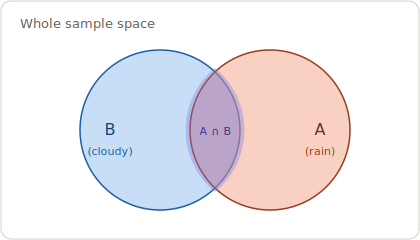

In [3]:
display(SVG(data=svg_string))



When we condition on **B**, we *ignore* everything outside the blue circle. The only question left is: of the blue region, how much overlaps with A (the purple slice)?

**Example (Rain & Cloudy)**

Imagine **100 days**:

- 30 days were **cloudy**.
- Of those cloudy days, **24** had **rain**.

$$P(\text{Rain} \mid \text{Cloudy}) = \frac{P(\text{Rain} \cap \text{Cloudy})}{P(\text{Cloudy})} = \frac{24/100}{30/100} = \frac{0.24}{0.30} = 0.8$$

So if it's cloudy, there's an **80% chance of rain**.

**Formula**

$$\boxed{\;P(A \mid B) = \dfrac{P(A \cap B)}{P(B)}\;}$$

The events A and B has can be dependent or indipendent: 

- Dependent events → knowing B changes the probability of A. `P(A|B) ≠ P(A)`
- Independent events → knowing B changes nothing. `P(A|B) = P(A)`

So conditional probability doesn't require dependence — it just becomes interesting when there's dependence. When events are independent, the conditional probability collapses back to the plain probability.

**Coin Flip Example**
A fair coin: `P(Heads) = 0.5`.

Question: I just flipped Heads. What's `P(Heads on next flip | Heads on this flip)`?
`P(Heads next | Heads now) = 0.5`

Still 0.5! 

The coin has no memory. The previous flip tells you nothing about the next one — they're independent.

$$ 
P(H_2 \mid H_1) = \frac{P(H_2 \cap H_1)}{P(H_1)} = \frac{0.5 \times 0.5}{0.5} = \frac{0.25}{0.5} = 0.5 = P(H_2)
$$

**Why it is important in Naive Bayes:**
Remember the "naive" assumption? 

Naive Bayes pretends all the words/features are independent. That's exactly the coin-flip situation — it assumes one word tells you nothing about another. In reality words are dependent (so it's a simplification), but assuming independence makes `P(w₁, w₂, w₃ | Class)` collapse into a simple multiplication of individual probabilities. That's the whole trick. 🎯

- [Numiqo - Conditional Probability Playground](https://numiqo.com/lab/conditional-probability)

### 2. Contingency Table

A **contingency table** (also called a *cross-tabulation*) is a simple grid that counts how often two things happen **together**. It's the easiest way to *see* the raw numbers behind conditional probability.

Here is the classic format (rows = one variable, columns = another):

| Product ↓ \ Soft drink → | Soda A | Soda B | Soda C |
|---|---|---|---|
| **Snack A** | 20 | 15 | 10 |
| **Snack B** | 10 | 25 | 15 |
| **Snack C** | 15 | 20 | 15 |

*Each cell = number of times that snack and drink were bought together.*

**Our Rain & Cloudy Example as a Contingency Table**

Using the same **100 days**, we cross-tabulate **weather** against **rain**:

| Weather ↓ \ Outcome → | Rain | No Rain | **Row Total** |
|---|---|---|---|
| **Cloudy** | 24 | 6 | **30** |
| **Not Cloudy** | 7 | 63 | **70** |
| **Column Total** | **31** | **69** | **100** |

This single table contains *everything* we need:

- $P(\text{Cloudy}) = 30/100 = 0.30$ (row total)
- $P(\text{Rain} \cap \text{Cloudy}) = 24/100 = 0.24$ (a cell)
- $P(\text{Rain}) = 31/100 = 0.31$ (column total)
- $P(\text{Rain} \mid \text{Cloudy}) = 24/30 = 0.8$ (cell ÷ row total)

> 💡 A contingency table makes probabilities concrete: every formula below is just **reading numbers off this grid**.

### 3. Bayes' Theorem

**Intuition**

Bayes' Theorem lets us **flip a conditional probability around**.

Sometimes we know `P(A | B)` but we actually want `P(B | A)`:

> We know *"if it's cloudy, how likely is rain?"* (`P(Rain | Cloudy)`)
> But we want *"it's raining — how likely is it that it's cloudy?"* (`P(Cloudy | Rain)`)

Bayes' Theorem connects these two directions.

**Main Idea**

It updates a **prior** belief into a **posterior** belief after seeing evidence:

$$\text{Posterior} = \frac{\text{Likelihood} \times \text{Prior}}{\text{Evidence}}$$

**Venn Diagram**


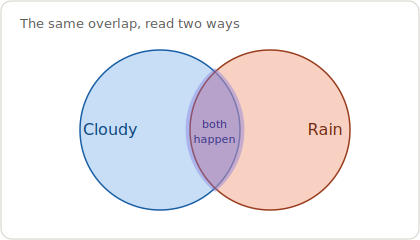

In [4]:
display(SVG(data=svg_string_1))



The **purple overlap** is the same patch either way. `P(Cloudy | Rain)` looks at it as a fraction of the orange circle; `P(Rain | Cloudy)` looks at it as a fraction of the blue circle. Bayes' Theorem is just the bridge between those two views.

**Simple Derivation (from Conditional Probability → Bayes)**

We start from the conditional probability formula, written **two ways**:

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)} \qquad\text{and}\qquad P(B \mid A) = \frac{P(A \cap B)}{P(A)}$$

Rearrange both to isolate the shared piece $P(A \cap B)$:

$$P(A \cap B) = P(A \mid B)\,P(B) \qquad\text{and}\qquad P(A \cap B) = P(B \mid A)\,P(A)$$

Since both equal the same thing, set them equal:

$$P(A \mid B)\,P(B) = P(B \mid A)\,P(A)$$

Now just divide both sides by $P(B)$:

$$\boxed{\;P(A \mid B) = \dfrac{P(B \mid A)\,P(A)}{P(B)}\;}$$

That's **Bayes' Theorem** — built entirely from conditional probability.

**Example (Rain & Cloudy)**

We want `P(Cloudy | Rain)` — *it's raining, how likely is it cloudy?*

We know from before:

- $P(\text{Rain} \mid \text{Cloudy}) = 0.8$
- $P(\text{Cloudy}) = 0.3$
- $P(\text{Rain}) = 0.31$ *(we'll see how to get this in the next section)*

$$P(\text{Cloudy} \mid \text{Rain}) = \frac{P(\text{Rain} \mid \text{Cloudy}) \cdot P(\text{Cloudy})}{P(\text{Rain})} = \frac{0.8 \times 0.3}{0.31} = \frac{0.24}{0.31} \approx 0.77$$

So if it's raining, there's about a **77% chance it's cloudy**.

**Formula**

$$\boxed{\;P(A \mid B) = \dfrac{P(B \mid A)\,P(A)}{P(B)}\;}$$

- [Numiqo - Bayes Thearom Playground](https://numiqo.com/lab/bayes-theorem)


#### Bayes' Theorem — The Distribution View

The key trick: don't plot the *classes* on the axes — plot the **data**. Each class becomes its own **probability distribution** over the data, and Bayes' Theorem just asks: *at the data point I observed, which class's curve is taller?*

$$P(\text{Class} \mid \text{Data}) = \frac{P(\text{Data} \mid \text{Class}) \times P(\text{Class})}{P(\text{Data})}$$


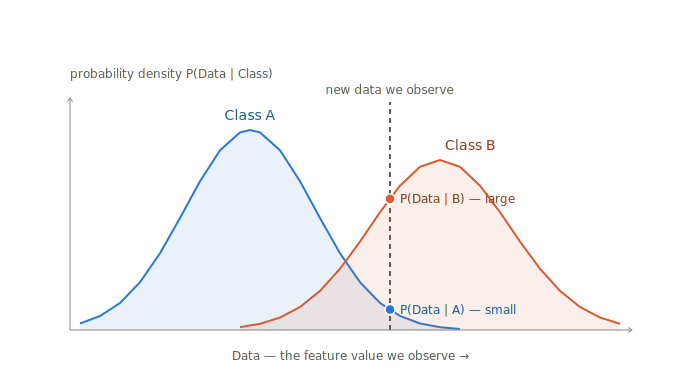

In [5]:
display(SVG(data=svg_string_5_small))


**Reading the Axes**

- **X-axis = the Data** — the feature value you observe (the *evidence*).
- **Y-axis = probability density** — `P(Data | Class)`, how likely each class is to *produce* that value.

Each class is its **own bell curve**. They overlap in the middle — the ambiguous zone.

**Each Bayes Term on the Plot**

| Term | What it *is* visually |
|---|---|
| `P(Data \| Class)` — **likelihood** | the **height of a curve** at the observed line |
| `P(Class)` — **prior** | the overall **size/weight** of a curve (common class → bigger curve) |
| `P(Data)` — **evidence** | the **combined height** of all curves at that point (normalizer) |
| `P(Class \| Data)` — **posterior** ← goal | **which curve wins** at the observed line |

**What We Know vs. Want**

- **Know** (from training): the shape/position of both curves `P(Data|Class)` + how common each class is `P(Class)`. This is the model.
- **Observe**: one new data point → the dashed line.
- **Want**: `P(Class | Data)` → read both curve heights at the line, the taller wins.

**This Example**

The dashed line falls in the overlap. Following it up: it crosses **Class A low** (small likelihood) but **Class B high** (large likelihood). Even though ambiguous, Class B is far more likely to produce it → **predict Class B** ✅

**The Crossover = Decision Boundary**

Where the two curves **cross**, `P(Data|A) = P(Data|B)`. Left of it → A wins; right → B wins. That crossover *is* the decision boundary — the same line you'd see in the "features on both axes" view, just from a different angle.

> This is exactly how **Gaussian Naive Bayes** thinks: each class is a bell curve over the feature, and classifying = checking whose curve is taller at your data point.



### 4. Law of Total Probability

**Why we need it**

Look at the **denominator** of Bayes' Theorem: $P(B)$, the *evidence*. In the example that was $P(\text{Rain}) = 0.31$ — but where did that number come from? 

The **Law of Total Probability** is the tool that computes it.

**Intuition**

An event (like *rain*) can happen through **several different routes**. To find its total probability, find the chance along **each route**, then **add them all up**.

> Rain can come on a **cloudy** day *or* on a **not-cloudy** day. Add the chance of rain from each → total chance of rain.

**Main Idea**

Split the whole world into **non-overlapping buckets that cover everything** (a *partition*). The target event lands partly in each bucket. Sum those parts.

**Venn Diagram (two buckets: B and not-B)**

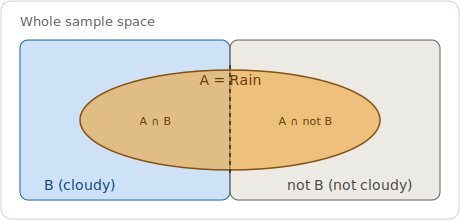

In [6]:
display(SVG(data=svg_string_2))



Event **A** (rain) is split by the dashed line into two slices: the part inside **B** and the part inside **not-B**. Add the two slices → all of A.

> `A` event must only fall into the only two events `B` and `-B` for this formula to work.

**Formula (two events: B and not-B)**

$$P(A) = P(A \cap B) + P(A \cap \neg B)$$

Which is basically (Using Conditional Probability Formula)

$$\boxed{\;P(A) = P(A \mid B)\,P(B) + P(A \mid \neg B)\,P(\neg B)\;}$$


**Example (Rain & Cloudy)**

- $P(\text{Cloudy}) = 0.3$, and $P(\text{Rain} \mid \text{Cloudy}) = 0.8$
- $P(\text{Not Cloudy}) = 0.7$, and $P(\text{Rain} \mid \text{Not Cloudy}) = 0.1$

$$P(\text{Rain}) = (0.8 \times 0.3) + (0.1 \times 0.7) = 0.24 + 0.07 = \mathbf{0.31}$$

That **0.31** is exactly the denominator we plugged into Bayes' Theorem above. ✅

**Extending to more than two buckets**

What if the weather has **three** types — Cloudy, Sunny, Overcast? Rain can come from any of them. The idea doesn't change: **more buckets just means more terms to add.**

**Venn Diagram (three buckets: B₁, B₂, B₃)**


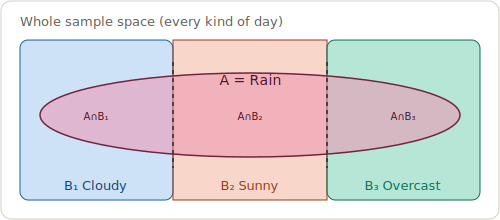

In [7]:
display(SVG(data=svg_string_3))

Now rain stretches across **three** slices. Two dashed lines cut it into three pieces — add all three.

**Formula (three events) and the general form**

$$P(A) = P(A \mid B_1)P(B_1) + P(A \mid B_2)P(B_2) + P(A \mid B_3)P(B_3)$$

Or compactly, for **any** number of buckets:

$$\boxed{\;P(A) = \sum_{i} P(A \mid B_i)\,P(B_i)\;}$$

**The two rules for valid buckets (a partition):**

1. **Cover everything** — every outcome falls into exactly one bucket.
2. **No overlap** — buckets can't share an outcome.

**Example (three weather types)**

| Weather | P(Weather) | P(Rain \| Weather) | Contribution |
|---|---|---|---|
| Cloudy | 0.3 | 0.6 | 0.6 × 0.3 = 0.18 |
| Sunny | 0.5 | 0.05 | 0.05 × 0.5 = 0.025 |
| Overcast | 0.2 | 0.8 | 0.8 × 0.2 = 0.16 |
| **Total** | **1.0** | — | **P(Rain) = 0.365** |

So across all three weather types, the overall chance of rain is **36.5%**.

**How It All Connects to Naive Bayes**

```
Conditional Probability  →  defines P(A | B)
        ↓
Bayes' Theorem           →  flips it: P(Class | Words) = P(Words | Class)·P(Class) / P(Words)
        ↓
Law of Total Probability →  computes the denominator P(Words) by summing over all classes
        ↓
Contingency Table        →  where the raw counts (the probabilities) come from
```

Naive Bayes classifies by computing the **posterior** `P(Class | features)` for every class using Bayes' Theorem, then picking the highest. The denominator (total probability of the features) is the **same** for every class, so in practice it's ignored when choosing the winner — but understanding it is what makes the whole method click.

### Expanding Bayes' Theorem with Total Probability

**The Problem**

Bayes' Theorem gives us:

$$P(A \mid B) = \frac{P(B \mid A)\,P(A)}{P(B)}$$

The numerator is easy — we usually know `P(B|A)` and `P(A)`.
But the denominator **`P(B)`** is often *not* given directly. We have to **build it**.

> NOTE: In Naive Bayes, the `P(B)=P(words)=P(w1​,w2​,…,wd​)` 

**The Fix: Law of Total Probability**

`B` can happen in only two ways: **with A**, or **without A** (`¬A`). Since `A` and `¬A` cover every possibility, we add both routes:

$$P(B) = P(B \mid A)\,P(A) + P(B \mid \neg A)\,P(\neg A)$$

**Visual — splitting the denominator**


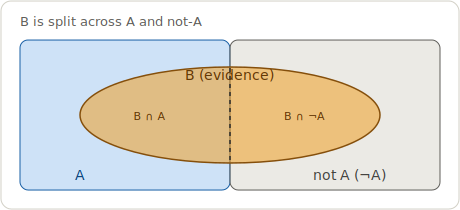

In [8]:
display(SVG(svg_string_4))


### The Full (Expanded) Bayes' Theorem

Substitute the expanded `P(B)` back in:

$$\boxed{\;P(A \mid B) = \dfrac{P(B \mid A)\,P(A)}{P(B \mid A)\,P(A) + P(B \mid \neg A)\,P(\neg A)}\;}$$

Now **everything** in the formula is something we can look up — no mystery denominator.

**Example (Rain & Cloudy)**

We want `P(Cloudy | Rain)`. So here **A = Cloudy**, **B = Rain**.

Known values:

| Term | Value |
|---|---|
| `P(Cloudy)` = P(A) | 0.3 |
| `P(Not Cloudy)` = P(¬A) | 0.7 |
| `P(Rain \| Cloudy)` = P(B\|A) | 0.8 |
| `P(Rain \| Not Cloudy)` = P(B\|¬A) | 0.1 |

**Step 1 — build the denominator** `P(Rain)`:

$$P(\text{Rain}) = (0.8 \times 0.3) + (0.1 \times 0.7) = 0.24 + 0.07 = 0.31$$

**Step 2 — apply full Bayes:**

$$P(\text{Cloudy} \mid \text{Rain}) = \frac{0.8 \times 0.3}{0.31} = \frac{0.24}{0.31} \approx 0.77$$

So if it's raining, there's about a **77% chance it's cloudy**.

#### Key Takeaway

> The denominator in Bayes' Theorem is **always** the total probability of the evidence — summed over every possible cause. With two causes it's `A` and `¬A`; with many causes it's a sum over all of them.

$$P(A \mid B) = \frac{P(B \mid A)\,P(A)}{\displaystyle\sum_i P(B \mid A_i)\,P(A_i)}$$

🔗 This sum-in-the-denominator is exactly what Naive Bayes computes across all its classes — and why it can ignore the denominator when only the *winning* class matters (it's the same for every class).

# Naive Bayes 

### Logistic Regression Vs Naive Bayes:

- Logistic Regression is a Discriminative Model: It directly models the probability of a class based on the features $P(Y\vert{}X)$. It tries to find a sharp line (decision boundary) that separates the data points.

- Naive Bayes is a Generative Model: It models how the data itself was generated $P(X\vert{}Y)$ and then uses Bayes' Theorem to calculate the class probability. It learns the distribution of each class separately.

### What is Naive Bayes: 
> The Naive Bayes Assumption

Instead of drawing boundaries, Naive Bayes asks a fascinating question: "If this data belonged to Class A, what is the probability it would look like this?" It relies on a beautifully simple rule—it assumes every single feature is completely independent of the others(while Regression uses feature's relationship to predict). While this assumption is almost never true in the messy real world, this "naivety" is actually its superpower. It allows Naive Bayes to be blindingly fast, require almost zero computer memory, and beat complex algorithms when working with tiny datasets or missing information.In real life, this elegant math runs the world behind the scenes. It powers your email's instant Spam Filters, drives real-time Sentiment Analysis to see if product reviews are happy or angry, and fuels Medical Diagnostics to predict patient risks based on a checklist of symptoms. It is the ultimate underdog algorithm: simple, incredibly fast, and shockingly effective.

### The Paradox: Why "Naive" Works So Well

The core paradox of Naive Bayes is that it makes terrible probability estimates, but excellent classification decisions. Its assumption—that features never interact—is almost always wrong. For example, in text, the word "New" and the word "York" are highly dependent on each other. Naive Bayes ignores this connection.Because it multiplies independent probabilities together, its final probability outputs get pushed to extremes (very close to 0 or 1). It is highly uncalibrated.Why it still wins:

Classification only cares about the ranking, not the exact percentage.If the true probability of a text being Spam is 80% and Not Spam is 20%, Logistic Regression might correctly calculate `[0.80, 0.20]`.Naive Bayes, due to its broken assumptions, might calculate `[0.9999, 0.0001]`.Even though the math is distorted, Spam still beats Not Spam. As long as the correct class gets the higher score, the final decision is 100% accurate. The structural error cancels itself out during the comparison.

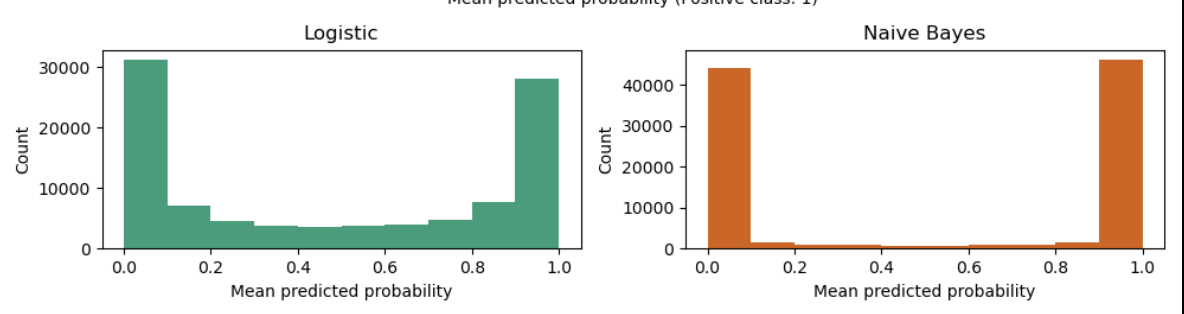
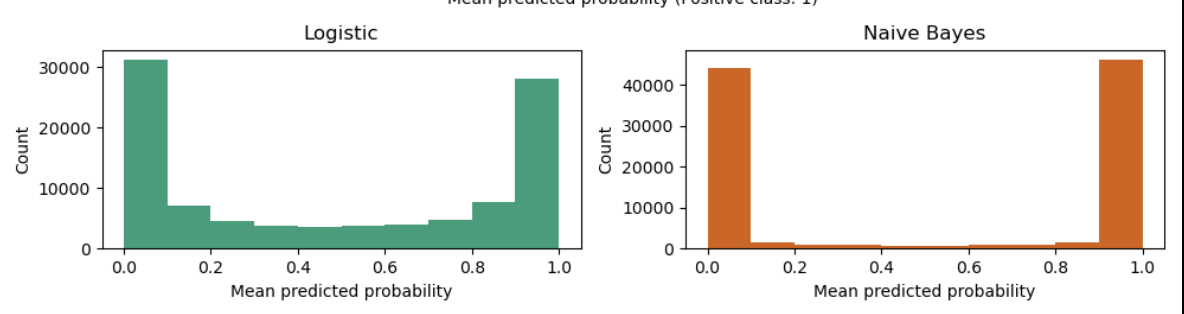
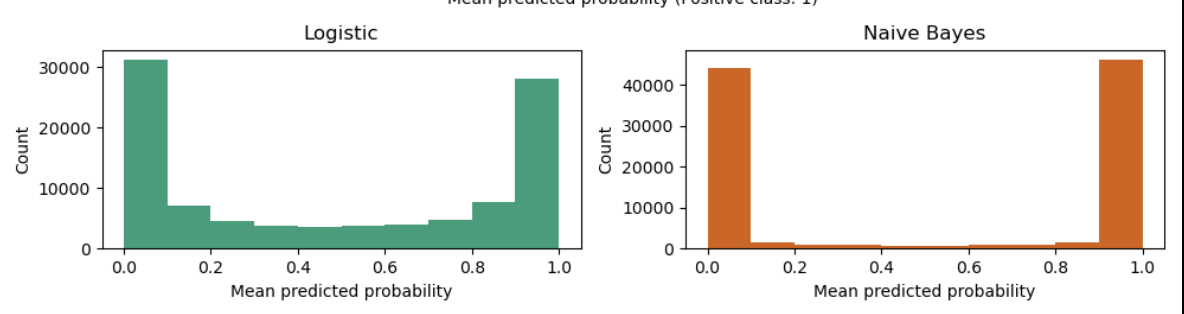

### Math Comparison: Logistic Regression vs. Naive Bayes
Here is a side-by-side comparison of how both algorithms handle the exact same prediction task.

####  The Dataset
We want to predict if a customer will Buy a product based on two features:

* Weekend (1 = Yes, 0 = No)
* Sale (1 = Yes, 0 = No)

####  Training History:

* Row 1: Weekend = 1, Sale = 1 $\rightarrow$ Buy
* Row 2: Weekend = 1, Sale = 0 $\rightarrow$ Buy
* Row 3: Weekend = 0, Sale = 1 $\rightarrow$ Buy
* Row 4: Weekend = 0, Sale = 0 $\rightarrow$ Don't Buy

####  Goal:
Predict the outcome for a new customer where Weekend = 1 and Sale = 1.

####  Logistic Regression (The Boundary Finder)
Logistic Regression treats features as a combined system. It learns weights to draw a decision boundary.

**The Formula**

It fits the data into the Sigmoid function to output a probability:
$$P(\text{Buy}) = \frac{1}{1 + e^{-(w_1 \cdot \text{Weekend} + w_2 \cdot \text{Sale} + b)}}$$ 

* $w_1, w_2$ = Weights (importance of each feature)
* $b$ = Bias (baseline tendency to buy)

####   How It Works

   1. Optimization: The algorithm cannot solve this in one step. It uses Gradient Descent loops to guess weights, check errors, and adjust them.
   2. Feature Interaction: It evaluates features together. It notices that if either Weekend or Sale is 1, the user buys.
   3. Output: It outputs a highly accurate, finely tuned probability (e.g., 0.93).

####  Naive Bayes (The Counter)
Naive Bayes looks at features completely separately. It assumes Weekend has nothing to do with Sale (the "Naive" assumption).

**The Formula**

Using Bayes' Theorem, it calculates a score for the class by multiplying separate probabilities:
$$\text{Score}(\text{Buy}) = P(\text{Weekend}=1 \mid \text{Buy}) \times P(\text{Sale}=1 \mid \text{Buy}) \times P(\text{Buy})$$ 
####  How It Works
It calculates the parts instantly by simply counting the training data:

* Base Probability of Buying: 3 out of 4 rows are "Buy".
$$P(\text{Buy}) = \frac{3}{4} = 0.75$$ 
* Weekend given Buy: Out of the 3 "Buy" rows, Weekend is 1 in two of them (Row 1 and Row 2).
$$P(\text{Weekend}=1 \mid \text{Buy}) = \frac{2}{3}$$ 
* Sale given Buy: Out of the 3 "Buy" rows, Sale is 1 in two of them (Row 1 and Row 3).
$$P(\text{Sale}=1 \mid \text{Buy}) = \frac{2}{3}$$ 

**The Final Calculation:**


$$\text{Score}(\text{Buy}) = \frac{2}{3} \times \frac{2}{3} \times 0.75 = 0.333$$ 
(The algorithm would run the exact same counting process for the "Don't Buy" class, get a score of 0.00, and choose Buy because 0.333 > 0.00)


####  Summary of Differences

| Feature | Logistic Regression | Naive Bayes |
|---|---|---|
| Strategy | Learns optimal weights via loops. | Counts frequencies instantly. |
| Perspective | Looks at features together. | Looks at features in complete isolation. |
| Math Speed | Slower (Iterative calculation). | Blazing fast (Simple arithmetic). |






### Terminology Prerequisites: The Building Blocks of Bayes' Theorem

In Naive Bayes, we want to predict a class ($Y$) given some evidence or features ($X$). To do this, the algorithm breaks the problem down into three core concepts: Prior, Likelihood, and Posterior.

**The Pseudo-Formula**

$$\text{Posterior} \propto \text{Likelihood} \times \text{Prior}$$ 
(Note: $\propto$ means "proportional to". We ignore the denominator because it stays the same for every class comparison).

#### Prior Probability: $P(Y)$

* What it is: Your baseline knowledge before looking at any new evidence. It represents the historical odds of an event happening.
* Simple Description: Out of all the data you have collected, how common is this specific class?
* Example: If 80% of all emails in your dataset are Spam, your Prior probability for Spam is 0.80. You assume a new email is 80% likely to be spam before even reading a single word of it.

#### Likelihood: $P(X \mid Y)$

* What it is: The probability of seeing a specific piece of evidence, assuming a certain class is already true.
* Simple Description: Given that we know the outcome is Class Y, what are the chances we would see Feature X?
* Example: Given that an email is definitely Spam, what is the probability that it contains the word "Crypto"?

#### Posterior Probability: $P(Y \mid X)$

* What it is: The updated probability of a class after taking the new evidence into account. This is the final answer your model calculates to make a prediction.
* Simple Description: Now that I see Feature X, what are the new odds that this is Class Y?
* Example: Now that I see the word "Crypto" in this specific email, what is the updated probability that this email is Spam?

#### Summary 

* Prior: What we know before checking the features.
* Likelihood: How well the features match a specific profile.
* Posterior: The final conclusion after combining our background knowledge with the new features.

#### Here is the example using Rain (the event) and Clouds (the evidence).

> "Posterior" literally means "after" (vs "prior" = before)
> Prior → (see evidence) → Posterior

 
####  Prior Probability (The Past Record)

* What it is: The general chance of an event happening before you look at any evidence.
* The Story: Over the last year, it rained on 10% of days.
* Symbol: $P(\text{Rain}) = 0.10$

#### Likelihood (The Clue's Track Record)

* What it is: How often the evidence appears on the days the event actually happens.
* The Story: You look only at past rainy days. On 90% of those days, it was cloudy.
* Symbol: $P(\text{Clouds} \mid \text{Rain}) = 0.90$

#### Posterior Probability (The Updated Prediction)

* What it is: The final chance the event will happen, now that you see the evidence.
* The Story: You wake up, look outside, and see clouds. Now you update your guess using the math below.
* Symbol: $P(\text{Rain} \mid \text{Clouds})$

<img src='https://av-eks-lekhak.s3.amazonaws.com/media/__sized__/article_images/image_9UVIeYz-thumbnail_webp-600x300.webp' width=400>

####  The Final Recipe
To get your final answer, you just multiply the past record by the clue's track record:
$$\text{Likelihood } (0.90) \times \text{Prior } (0.10) = \mathbf{0.09}$$ 
(You run the same math for "No Rain", and whichever score is bigger wins the prediction!)

# Multinomial Naive Bayes Explained 

A classifier that turns Bayes' Theorem into a fast prediction machine using nothing but **word counts**. This note assumes you already know conditional probability, Bayes' Theorem, and total probability (covered in the prerequisite notes) — here we focus on *how Naive Bayes uses them*.

#### 1. The Idea

Naive Bayes plugs your classes into Bayes' Theorem:

$$P(\text{Class} \mid \text{Data}) = \frac{P(\text{Data} \mid \text{Class}) \times P(\text{Class})}{P(\text{Data})}$$

Three names to know:

- **Prior** `P(Class)` → belief *before* seeing the data (e.g. how common spam is overall)
- **Likelihood** `P(Data | Class)` → how well the data fits a class
- **Posterior** `P(Class | Data)` → updated belief *after* seeing the data ← **the goal**

> The denominator `P(Data)` is the **same for every class**, so it never changes *which* class wins. That's why from here on we use `∝` (proportional to) and simply drop it.


#### 2. Warm-Up: A Single Clue

You get an email — is it **spam**?

**Prior** (before reading anything):
```
P(spam) = 0.4        (40% of all mail is spam)
```

Now you spot the word **"FREE"**. Update the belief:

**Posterior** (after the clue):
```
P(spam | "FREE") = 0.9      (now 90% likely spam)
```

The evidence pushed belief from **0.4 → 0.9**. That's the whole spirit of Naive Bayes — start with a prior, let each word nudge it.


#### 3. From One Clue to a Whole Email

Real emails have many words. Take a 3-word email: **w₁ w₂ w₃**.

**High level** — we want the posterior for each class:

$$P(\text{Class} \mid \text{Email}) \propto P(\text{Email} \mid \text{Class}) \times P(\text{Class})$$

The email *is* its words, so:

$$P(\text{Email} \mid \text{Class}) = P(w_1, w_2, w_3 \mid \text{Class})$$

**Detailed (the honest version)** — expanded properly, each word depends on the ones before it:

$$P(w_1, w_2, w_3 \mid \text{spam}) = P(w_1 \mid \text{spam}) \cdot P(w_2 \mid w_1, \text{spam}) \cdot P(w_3 \mid w_2, w_1, \text{spam})$$

That last term, `P(w₃ | w₂, w₁, spam)`, is the wall: to estimate it we'd need to have seen that *exact* word sequence in training. Almost no combination ever repeats. **Impossible to count reliably.**

**The "naive" shortcut** — assume each word is independent of the others (given the class). Every messy conditional term simplifies:

$$P(w_2 \mid w_1, \text{spam}) \approx P(w_2 \mid \text{spam}) \qquad P(w_3 \mid w_2, w_1, \text{spam}) \approx P(w_3 \mid \text{spam})$$

Now the impossible joint probability becomes a simple **product of single-word probabilities** — each of which is just a count. *(Why this assumption is OK is covered in Section 8.)*


#### 4. The Final Formula

$$\boxed{\;P(\text{Class} \mid w_1, w_2, w_3) \propto P(\text{Class}) \times P(w_1 \mid \text{Class}) \times P(w_2 \mid \text{Class}) \times P(w_3 \mid \text{Class})\;}$$

Compute this score for **each** class → **the largest posterior wins.**

Each word probability is pure counting:

$$P(\text{word} \mid \text{Class}) = \frac{\text{count of word in that class}}{\text{total words in that class}}$$

**Worked Example**

Training data (a tiny mailbox):

| Word | Count in **Normal** | Count in **Spam** |
|---|---|---|
| Dear | 8 | 2 |
| Friend | 5 | 1 |
| Lunch | 3 | 0 |
| Money | 1 | 4 |
| **Total words** | **17** | **7** |

Priors (8 normal messages, 4 spam): `P(Normal) = 0.67`, `P(Spam) = 0.33`.

**New email: "Dear Friend"**

```
Normal score = 0.67 × (8/17) × (5/17) = 0.67 × 0.47 × 0.29 ≈ 0.091
Spam   score = 0.33 × (2/7)  × (1/7)  = 0.33 × 0.29 × 0.14 ≈ 0.014
```

Normal wins → classified **Not Spam** ✅


#### 5. In Short

> **Posterior** = your updated probability of a class after seeing the words. Naive Bayes computes it for every class, then picks the highest.
>
> **Prior → (see the words) → Posterior**

#### 6. ⚠️ The Zero Problem

Watch what happens with a different email.

**New email: "Money Lunch"** — "Money" is *very* spammy (4/7!), so we'd expect a high spam score:

```
Spam score = P(Spam) × P(Money|Spam) × P(Lunch|Spam)
           = 0.33    × (4/7)         × (0/7)
           = 0.33    × 0.57          × 0
           = 0   ❌
```

The word **"Lunch" never appeared in spam training** → `P(Lunch | Spam) = 0` → it drags the **entire product to zero**, wiping out the strong "Money" signal.

One unseen word shouldn't veto everything. This is too harsh.

#### 7. The Fix: Laplace Smoothing

**Add 1 to every word count** so nothing is ever exactly zero:

$$P(\text{word} \mid \text{Class}) = \frac{\text{count} + 1}{\text{total} + V}$$

where `V` = vocabulary size (here 4: Dear, Friend, Lunch, Money).

Recomputing the killer term:

$$P(\text{Lunch} \mid \text{Spam}) = \frac{0 + 1}{7 + 4} = \frac{1}{11} \approx 0.09$$

Now it's small but **not zero** — the score survives, and "Money" gets to have its say.

**Why the +1 (the "pseudocount" logic):** we pretend we saw every word one extra time. It encodes a sensible belief — *"just because I haven't seen this word in spam yet doesn't mean it's impossible."* It keeps rare/unseen words from breaking the whole model.

**In sklearn:** `MultinomialNB` does this **by default** with `alpha = 1` (that's exactly add-1 / Laplace smoothing). You can lower `alpha` for softer smoothing or tune it — but you never have to add it yourself. This is quietly protecting your IMDB sentiment project already.


#### 8. The "Naive" Assumption — and Why It's Fine

The whole method rests on one bold pretense from Section 3:

> **Every word is independent of the others, given the class.**

This is "naive" because it's **not true** — language has order and grammar. The clearest way to see the flaw:

**"Dear Friend" vs "Friend Dear"**

```
"Dear Friend" → P(Class) × P(Dear|Class) × P(Friend|Class)
"Friend Dear" → P(Class) × P(Friend|Class) × P(Dear|Class)
```

Multiplication order doesn't matter, so **both get the *exact same* score.** Naive Bayes literally *cannot tell them apart* — it treats an email as a **bag of words**, ignoring order entirely. A human knows word order carries meaning (think "not good" vs "good... not"), but Naive Bayes throws that away.

**So why does it still work so well?**

For classification, you usually don't need grammar — you just need to know **which words showed up**. The mere presence of "free," "money," "winner" is enough to flag spam, regardless of arrangement. By ignoring word dependencies, the model:

- needs far less data (count single words, not combinations),
- runs extremely fast,
- and stays surprisingly accurate.

> **The takeaway:** Naive Bayes trades a false assumption for enormous simplicity — and for tasks like spam and sentiment, that trade is a bargain.


#### One-Glance Recap

```
Bayes' Theorem          →  P(Class|words) ∝ P(words|Class) · P(Class)
Naive independence       →  P(words|Class) = P(w₁|Class)·P(w₂|Class)·…  (a product of counts)
Predict                  →  compute score per class, pick the highest
Zero problem             →  one unseen word zeroes everything
Laplace smoothing (α=1)  →  add 1 to every count so nothing is impossible
Bag of words             →  order ignored ("Dear Friend" = "Friend Dear")
```

## Arithmetic Underflow & the Log-Probability Trick

A companion note to Naive Bayes — explaining *why* real implementations add logarithms instead of multiplying probabilities directly.

#### 1. What Is Arithmetic Underflow?

> **Underflow** happens when a number becomes *too small* for the computer to physically store, so it gets rounded all the way down to **zero**.

Every number in a computer has a fixed budget of bits. When a calculation produces a value smaller than the tiniest number those bits can represent, the computer can't hold it — the result silently collapses to `0.0`.

For standard 32-bit floats (IEEE 754 `float32`), that limit is roughly:

$$1.4 \times 10^{-45}$$

Anything smaller than this **underflows to zero**.

#### 2. Why It Happens (The Mechanics)

A floating-point number is stored in two parts:

- **Mantissa** — the significant digits (the "value")
- **Exponent** — the scale (where the decimal point sits)

Both have a **fixed number of bits**. The trouble appears during **addition**:

1. To add two numbers, the computer must line them up to the **same exponent**.
2. This means shifting the smaller number's digits to the right.
3. If one number is *much* smaller than the other, its digits get shifted **past the edge** of the available bits.
4. Those digits fall off, and the small number effectively becomes **zero** in the sum.

So the small value doesn't just get inaccurate — during that operation it's treated as if it were **absolute zero**.


#### 3. Why This Is a Big Deal in Machine Learning

ML constantly multiplies **probabilities** — fractions between 0 and 1. And multiplying fractions *shrinks* the result fast:

```
0.1 × 0.1 × 0.1 = 0.001
```

Each multiplication pushes the number closer to zero. In a model like Naive Bayes, a single document might multiply **hundreds** of word probabilities together. Long before you finish, the running product underflows to `0.0` — and now every class scores zero, making prediction impossible.

**This is exactly the numerical wall Naive Bayes hits** when it computes `P(w₁) × P(w₂) × … × P(w_d)`.


#### 4. The Core Insight: *Shrinking* vs. *Shifting*

Picture your computer's memory as a **fixed-width notebook page**.

**Without logs (multiplying):**
Every multiplication adds more zeros after the decimal point, stretching the number further right across the page:
```
0.1 → 0.01 → 0.001 → 0.0001 → … → falls off the page → 0
```
Once it runs off the edge, the computer sees nothing left and rounds to zero. You're **shrinking** the number until it disappears.

**With logs:**
A logarithm answers *"how many zeros are after the decimal point?"* — it tracks the **scale** of the number, not the fragile fraction itself. Instead of a tiny value sliding off the page, you store a small, manageable number like `-16`. You're **shifting** to a safe representation instead of shrinking into oblivion.

| | Multiplying fractions | Adding logs |
|---|---|---|
| What you track | the tiny fraction itself | its *scale* (order of magnitude) |
| Behavior | shrinks toward 0 | stays a normal-sized number |
| Risk | underflow → 0 | safe |



#### 5. Worked Example

Say we need the total probability:

$$\text{Total} = 0.0001 \times 0.0001 \times 0.0001 \times 0.0001$$

### Method 1 — The Dangerous Way (Direct Multiplication)

Watch the number collapse:

```
0.0001 × 0.0001                     = 0.00000001        (10⁻⁸)
0.00000001 × 0.0001                 = 0.000000000001    (10⁻¹²)
0.000000000001 × 0.0001             = 0.0000000000000001 (10⁻¹⁶)
```

If the computer's limit were 15 decimal places, that final `10⁻¹⁶` result would drop **below the limit and become exactly 0**. And this is only *four* numbers — multiply a hundred of them and **even the most powerful computer underflows to absolute zero.**

### Method 2 — The Safe Way (Using Logarithms)

Take the base-10 log of each fraction *first*. Since `10⁻⁴ = 0.0001`:

$$\log_{10}(0.0001) = -4$$

Then use the fundamental log rule that turns **multiplication into addition**:

$$\log(A \times B) = \log(A) + \log(B)$$

So instead of multiplying four tiny fractions, just **add four small integers**:

$$\text{Log Total} = (-4) + (-4) + (-4) + (-4) = -16$$

The answer `-16` is a perfectly ordinary number the computer stores with ease. No shrinking, no underflow — same information, safe representation.



#### 6. Key Takeaway

> Multiplying many small probabilities drives the result toward zero until it **underflows** and is lost. Taking logs converts those multiplications into **additions of manageable numbers**, sidestepping underflow entirely — while preserving which value is largest.

This is why Naive Bayes (and most probabilistic ML) computes scores as **sums of log-probabilities**:

$$\log P(\text{Class}) + \sum_{i} \log P(w_i \mid \text{Class})$$

Because logs preserve order (a bigger probability always has a bigger log), the class with the **highest log-score is still the winner** — you get the same prediction, just without the numerical crash.

## Naive Bayes: Time Complexity

Why Naive Bayes is one of the **fastest** classifiers in machine learning — and where that speed pays off in the real world. A companion note to the main Naive Bayes note.


#### The Variables

| Symbol | Meaning |
|---|---|
| `n` | number of training documents |
| `d` | average number of features (words) per document |
| `c` | number of classes |
| `V` | vocabulary size (unique words) |


#### Training Time → **O(n · d)**

Training Naive Bayes is just **counting**. It makes **one single pass** over the data:

- for each document (`n` of them)…
- …look at each word (`d` of them) and increment a counter.

That's `n × d` — literally "touch every word in the dataset once." After counting, building the probability table is a cheap `O(c · V)` finishing step (usually tiny next to the counting).

**No gradient descent. No epochs. No iterations. No matrix inversion.** One pass and you're done.

#### Compared to Its Neighbors

| Algorithm | Training cost | Why |
|---|---|---|
| **Naive Bayes** | **O(n · d)** — one pass | just counting |
| Logistic Regression | O(n · d · epochs) | iterative gradient descent |
| SVM (kernel) | O(n²) – O(n³) | pairwise comparisons |
| Neural Network | huge × many epochs | repeated backpropagation |

This single-pass counting is what makes Naive Bayes feel almost *free* to train.



#### Inference / Testing Time → **O(c · d)**

To classify **one** new document:

- for each class (`c`)…
- …combine the probabilities of its `d` words.

So it's `c × d`. For binary tasks (spam/not-spam, positive/negative), `c = 2`, so inference is effectively:

$$O(d) \quad\text{— linear in the length of the document}$$

A short tweet takes a handful of operations. Prediction is **blazing fast**.

#### The Detail That Makes It Even Faster 🔍

Real implementations don't multiply probabilities — they **add logs** (to avoid underflow, see the log-probability note). So inference becomes:

$$\log P(\text{Class}) + \sum_i \log P(w_i \mid \text{Class})$$

That's just **table lookups + additions** — no expensive math. This is why Naive Bayes can run on a smartwatch, a microcontroller, or a $5 edge device. It's arithmetic a 1970s calculator could handle.



#### Main Takeaway

> **Naive Bayes is fast because it never optimizes — it just counts once (training) and looks up + adds (inference).** Training is linear and single-pass; prediction is linear in document length. Both scale gracefully to huge data on cheap hardware.

Two superpowers fall out of this:

1. **Incremental / online learning** — since training is just counting, you can absorb a *single new example* in `O(d)` by bumping a few counters. No full retrain.
2. **Embarrassingly parallel** — counting splits cleanly across machines (MapReduce-style): count each shard independently, then merge the counts.



#### Real-World Applications Where This Speed Pays Off

**📧 Bayesian spam filters (the classic)**
The famous case. Paul Graham's 2002 essay *"A Plan for Spam"* launched the Bayesian-filter era precisely because it was cheap and *personalizable*. When you click "mark as spam," the filter updates **instantly** — it just increments word counts for your account. A neural net would need retraining; Naive Bayes needs a few counter bumps, so every user gets their own adapting filter for almost nothing.

**🐦 Social-media firehose sentiment**
Platforms handle millions of posts per minute. Naive Bayes's `O(d)` inference tags a flood of short texts in real time on modest hardware, where a heavier model would need a GPU farm to keep up.

**🌐 Language detection**
That instant *"this page is in Portuguese → translate?"* prompt often uses a Naive-Bayes-style character/word model. It must decide in **milliseconds** as pages load — lookup-and-add speed is perfect for it.

**📰 Real-time news / document routing**
Wire services and large inboxes auto-tag incoming articles into categories (sports, finance, politics) on arrival. New topics appear constantly, and NB's online updating lets the system adapt without downtime.

**⚕️ Fast triage / screening tools**
For quick, interpretable first-pass classification over many symptom/feature inputs (flagging, not final diagnosis), NB's speed and transparency make it a useful lightweight screener.

**🚀 The universal "first baseline"**
Almost every text-classification project *starts* with Naive Bayes — not because it's the most accurate, but because you get a working model in **seconds**. It instantly tells you whether the problem is even learnable before you invest in heavier models. Its speed makes it the perfect sanity check.



#### The Through-Line

> Anywhere you need **real-time decisions, constant model updates, tiny hardware, or a fast baseline**, Naive Bayes's "just count and add" nature is a genuine practical edge — often worth more than the extra accuracy a slower model would buy.

#### One-Page Recap

```
Training   →  O(n · d)   one counting pass, no optimization
Inference  →  O(c · d)   ≈ O(d) for binary — linear in doc length
Logs       →  lookups + additions, runs on tiny hardware
Bonus 1    →  online learning: update with one example in O(d)
Bonus 2    →  embarrassingly parallel: count shards, merge counts
Payoff     →  spam filters, live sentiment, language ID, fast baselines
```

### Bridge Note: Different Ways to Compute `P(words | Class)`

Before learning Bernoulli NB, it's worth pausing on **what actually changes** between Naive Bayes variants — because it's less than you'd think.

**What Stays the Same**

Every Naive Bayes variant uses the **exact same high-level skeleton**:

$$P(\text{Class} \mid \text{Email}) \propto P(\text{Class}) \times P(\text{Email} \mid \text{Class})$$

Bayes' Theorem, the prior, the "pick the highest score wins" logic — none of that ever changes.

**What Changes: Only the Likelihood `P(Email | Class)`**

The **only** thing that gets redefined between variants is *how we compute* `P(Email | Class)` — i.e. how we turn a document into a probability. Multinomial NB (which you just learned) is **one specific way** to do this. Bernoulli is a **different way** — same slot in the formula, different plug-in.

| | **Multinomial** | **Bernoulli** (coming up next) |
|---|---|---|
| Email treated as | a **sequence of word occurrences** | a **binary vector over the whole vocabulary** |
| Formula | $\prod_i P(w_i \mid \text{Class})$ — one factor per **word occurrence** | $\prod_i P(i\mid y)^{x_i}(1-P(i\mid y))^{1-x_i}$ — one factor per **vocabulary word**, present or not |
| Words missing from the email | simply **left out** of the product | **included** — contributing an absence factor `(1 − P)` |
| Each factor answers | "how *often* does this word occur in this class?" | "does this word *tend to appear* in this class or not?" |

**The Formula, Side by Side**

$$\underbrace{P(\text{Class} \mid \text{Email}) \propto P(\text{Class}) \times P(\text{Email} \mid \text{Class})}_{\text{same skeleton, every variant}}$$

$$P(\text{Email} \mid \text{Class}) = \begin{cases} \displaystyle\prod_{\text{word occurrences}} P(w \mid \text{Class}) & \textbf{Multinomial} \text{ — counts} \\[8pt] \displaystyle\prod_{\text{every vocab word}} P(i\mid y)^{x_i}\big(1-P(i\mid y)\big)^{1-x_i} & \textbf{Bernoulli} \text{ — presence/absence} \\[8pt] \dfrac{1}{\sqrt{2\pi\sigma^2}}\, e^{-\frac{(x-\mu)^2}{2\sigma^2}} & \textbf{Gaussian} \text{ — continuous} \end{cases}$$

<img src="https://towardsdatascience.com/wp-content/uploads/2024/08/1oBpcc5GIf6hcZoxNqpslqg.png" width="500">

**The Takeaway**

> **One outer formula. Three different plug-ins for the likelihood** — chosen based on what kind of feature you're working with (counts, binary presence, or continuous values). That's the entire relationship between the NB variants; nothing else about Naive Bayes changes.

With that lens set, the natural next question is: *what does it actually mean to compute the likelihood by "presence or absence" instead of by counting?* That's Bernoulli Naive Bayes.

# Bernoulli Naive Bayes

The flavor of Naive Bayes for **binary features** — where every feature is simply *present or absent* (1 or 0). A companion note to the main Naive Bayes and Multinomial notes.


#### The Core Idea

Bernoulli NB asks only one thing about each word: **is it there or not?** It ignores *how many times* a word appears — only **whether it appears at all**.

```
Email: "free free free money"

Multinomial sees:  free = 3, money = 1     (counts)
Bernoulli sees:    free = 1, money = 1     (present / absent only)
```

Each document becomes a **binary vector** over the entire vocabulary:

```
Vocab:  [win, free, meeting, dear]
Email "win free"  →  [1, 1, 0, 0]
```


**The Formula**

The general smoothed (categorical) form is:

$$P(X_i = j \mid y) = \frac{n_{ij} + \alpha}{n_i + \alpha \cdot C}$$

$$P(X_i = 1 \mid y) = \frac{\text{docs in class } y \text{ containing word } i \;+\; \alpha}{\text{total docs in class } y \;+\; 2\alpha}$$


**Bernoulli is the special case where `C = 2`** — each feature has exactly two possible values (present or absent)

And the notation convention is slightly different for `n_{ij}` means "count of feature `i` taking value `j`" (not "in class y"), and the whole expression is implicitly within class `y` (that's what the `n_i` denominator represents — total count for feature `i` in that class). So:

`j` indexes the value the feature takes (for Bernoulli, `j ∈ {0, 1}`)
The class `y` is fixed/implicit throughout (everything is "given y")

So for Bernoulli specifically, setting `j = 1` (word present):
For the "present" case it becomes:

$$P(X_i = 1 \mid y) = \frac{n_i + \alpha}{N_y + \alpha \cdot C}, \qquad C = 2$$

| Term | Meaning (Bernoulli) |
|---|---|
| `n_i` | number of **documents in class y** that contain word `i` |
| `N_y` | total number of documents in class y |
| `α` | smoothing constant (default `α = 1`, Laplace) |
| `i` | the `i`th word in the email |
| `j` | `j ∈ {0, 1}` 0 means absent and 1 means present |
| `y` | the class; 1 - target class |
| `C` | number of possible values = **2** (present / absent) |

> ⚠️ **Key distinction:** Bernoulli counts **documents**, not word occurrences.
> It asks *"how many spam emails **contained** 'free'?"* — not *"how many times did 'free' appear?"*

#### Interpretation for the Whole Document — `P(x | y)`

A document isn't just *one* word — it's a **vector** `x = [x₁, x₂, …, x_V]` covering the **entire vocabulary** (V words), where each `xᵢ` is 1 (present) or 0 (absent).

To get the probability of the *whole document* given a class, multiply the per-word probability across **every word in the vocabulary** — using the "present" formula when the word showed up, and its flip-side `(1 − P)` when it didn't:

$$P(x \mid y) = \prod_{i=1}^{V} P(X_i = 1 \mid y)^{x_i} \cdot \big(1 - P(X_i = 1 \mid y)\big)^{(1 - x_i)}$$

#### Reading it in plain words

For **every single word in the vocabulary** (not just the ones in this email):

| If the word... | ...contributes this factor |
|---|---|
| **appears** in the document (`xᵢ = 1`) | `P(Xᵢ = 1 \| y)` — its "presence" probability |
| **doesn't appear** (`xᵢ = 0`) | `1 − P(Xᵢ = 1 \| y)` — its "absence" probability |

The exponents `xᵢ` and `(1 − xᵢ)` are just a compact trick: whichever one is `0` makes that whole factor equal to **1** (multiplying by 1 does nothing), so only the *relevant* branch actually contributes for each word.

### 🎯 The One Thing That Makes Bernoulli Different

Bernoulli **explicitly rewards absence.** For each document it multiplies over the **whole vocabulary** — including the words that *aren't* present:

$$P(x \mid y) = \prod_i P(i \mid y)^{\,x_i} \cdot \big(1 - P(i \mid y)\big)^{\,(1 - x_i)}$$

Reading the two cases:

- Word **present** (`xᵢ = 1`) → multiply by `P(i | y)`
- Word **absent** (`xᵢ = 0`) → multiply by `(1 − P(i | y))`

So a *missing* word is itself evidence. Multinomial NB ignores absent words completely; Bernoulli says:

> *"Spam emails usually **don't** contain 'meeting' — so 'meeting' being missing makes this email look **more** like spam."*

That built-in use of absence is the whole personality of Bernoulli NB.

#### Worked Example

Training set: **4 spam + 4 ham** emails. We count **document presence** (how many docs contain each word):

| Word | in Spam docs (/4) | in Ham docs (/4) |
|---|---|---|
| win | 3 | 0 |
| free | 3 | 1 |
| meeting | 0 | 4 |
| dear | 0 | 3 |

$$P(X_i = j \mid y) = \frac{n_{ij} + \alpha}{n_i + \alpha \cdot C}$$

**Probabilities** with `α = 1`, `C = 2` → denominator `= 4 + (1 × 2) = 6`:

| Word | P(word=1 \| Spam) | P(word=1 \| Ham) |
|---|---|---|
| win | (3+1)/6 = 0.67 | (0+1)/6 = 0.17 |
| free | (3+1)/6 = 0.67 | (1+1)/6 = 0.33 |
| meeting | (0+1)/6 = 0.17 | (4+1)/6 = 0.83 |
| dear | (0+1)/6 = 0.17 | (3+1)/6 = 0.67 |

#### Classify new email: **"win free"** → vector `[1, 1, 0, 0]`

$$P(x \mid y) = \prod_i P(i \mid y)^{\,x_i} \cdot \big(1 - P(i \mid y)\big)^{\,(1 - x_i)}$$


We include the **absent** words (meeting, dear) using their `(1 − P)` terms:

```
Spam = P(Spam) × P(win=1|S) × P(free=1|S) × (1−P(meeting=1|S)) × (1−P(dear=1|S))
     = 0.5 × 0.67 × 0.67 × (1−0.17) × (1−0.17)
     = 0.5 × 0.67 × 0.67 × 0.83 × 0.83
     ≈ 0.154

Ham  = P(Ham) × P(win=1|H) × P(free=1|H) × (1−P(meeting=1|H)) × (1−P(dear=1|H))
     = 0.5 × 0.17 × 0.33 × (1−0.83) × (1−0.67)
     = 0.5 × 0.17 × 0.33 × 0.17 × 0.33
     ≈ 0.0016
```

**Result:** Spam (0.154) ≫ Ham (0.0016) → classified **Spam** ✅

**Why it won so decisively:** not only were "win" and "free" present (spammy signals), but "meeting" and "dear" were **absent** — and their absence is exactly what ham emails are built on. Bernoulli turned the missing words into evidence.


Vocabulary = `{win, free, meeting, dear}`. Document = "win free" → `x = [1, 1, 0, 0]`.

$$P(x \mid y) = \underbrace{P(\text{win}{=}1|y)}_{x_1=1} \times \underbrace{P(\text{free}{=}1|y)}_{x_2=1} \times \underbrace{\big(1-P(\text{meeting}{=}1|y)\big)}_{x_3=0} \times \underbrace{\big(1-P(\text{dear}{=}1|y)\big)}_{x_4=0}$$

This is exactly the calculation from the "win free" worked example 

"win" and "free" contribute their *presence* probabilities, while "meeting" and "dear" contribute their *absence* probabilities. That's the mechanism that lets Bernoulli NB treat a missing word as real evidence, not something to ignore.


#### Bernoulli vs Multinomial — When to Use Which

| | **Bernoulli NB** | **Multinomial NB** |
|---|---|---|
| Feature type | word **present / absent** (0/1) | word **counts** (0, 1, 2, 3…) |
| Cares about | *does* the word appear | *how often* it appears |
| Uses absent words? | **Yes** — absence is evidence | No — ignores them |
| Counts | **documents** containing the word | **occurrences** of the word |
| Best for | short texts: spam, subject lines, tweets | longer docs: topic/news classification |
| `C` in formula | 2 | vocabulary-based (counts) |

**Rule of thumb:**

- **Short** documents where a word either matters or doesn't (tweets, spam, subject lines) → **Bernoulli**
- **Longer** documents where repetition carries meaning (articles, reviews) → **Multinomial**

**In sklearn:** `BernoulliNB` (same `alpha = 1` default). It can even binarize count data automatically via the `binarize` parameter.

## One-Page Recap

```
Feature      →  binary: word present (1) or absent (0)
Formula      →  P(Xᵢ=1|y) = (nᵢ + α) / (N_y + α·C),  with C = 2
Counts       →  documents containing the word, not total occurrences
Signature    →  absent words count as evidence via (1 − P) terms
Best for     →  short texts where presence matters more than frequency
sklearn      →  BernoulliNB(alpha=1, binarize=…)
```

## Prerequisites of Gaussian Naive Bayes

### The Normal Distribution — Density vs Probability

A prerequisite for Gaussian Naive Bayes: understanding what the **y-axis** of a bell curve actually means — and why it is *not* a probability.

**The Key Idea**

> The **height** of the curve at a point is *not* a probability. The **area** under the curve across a range *is*.

This is the single most important thing to internalize about continuous distributions like the normal curve — and it's exactly what Gaussian Naive Bayes exploits.

**Height = Likelihood (Density), Not Probability**

At the red point `x₁`, the curve's height `f(x₁)` is called the **probability density** (or **likelihood**). It tells you *how relatively likely* values near `x₁` are compared to other values — a taller point is more likely than a shorter one.

But it is **not itself a probability**:

- A probability must be between 0 and 1.
- A density `f(x)` can be **greater than 1** (e.g. a very tight, narrow bell curve can peak well above 1) — proof by itself that it isn't a probability.
- The probability of hitting **any exact single value** on a continuous curve is actually **zero** — there are infinitely many possible values, so any one specific value has vanishing chance.

**Area = Probability**

The green shaded region between `a` and `b` **is** a real probability — it's the **area under the curve** across that range:

$$P(a < X < b) = \int_a^b f(x)\, dx$$

The **entire area under the whole curve always equals 1** — because the value must fall *somewhere*. A narrow slice of that area gives you the probability of landing in that slice.

| | Height at one point | Area across a range |
|---|---|---|
| Symbol | `f(x)` | `P(a < X < b)` |
| Called | density / likelihood | probability |
| Range of values | can exceed 1 | always between 0 and 1 |
| What it answers | "how relatively likely is this exact value?" | "what fraction of outcomes fall in this range?" |

**The Formula**

$$f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \, e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

| Term | Meaning |
|---|---|
| `x` | the value being evaluated |
| `μ` | the mean — where the curve is centered |
| `σ` | the standard deviation — how wide/spread out the curve is |
| `f(x)` | the **density** at `x` — the curve's height there |

**Example**

Say heights follow a normal distribution with `μ = 5.9 ft`, `σ = 0.3`.

**Plugging in `x = 5.7`:**

$$f(5.7) = \frac{1}{\sqrt{2\pi (0.3)^2}} \, e^{-\frac{(5.7-5.9)^2}{2(0.3)^2}} \approx 1.19$$

This `1.19` is a **density**, not a probability — notice it's already bigger than 1. It tells you "a height of 5.7 is fairly likely for this class relative to other heights," but it does **not** mean "there's a 119% chance."

To get an actual probability, you'd need a *range* — e.g. `P(5.6 < Height < 5.8)` — which would be some proper value between 0 and 1, equal to the area of that thin slice under the curve.


**Why This Matters for Gaussian Naive Bayes**

Gaussian NB plugs a feature value directly into `f(x)` and uses the resulting **density** to compare classes — *"which class's curve is taller here?"* It never needs to compute an actual area/probability, because for **comparing** which class wins, the raw density is all that's needed — the taller curve at that point wins, exactly like comparing two heights rather than two areas.

> **Takeaway:** the number Gaussian Naive Bayes computes for a data point is a **likelihood/density**, not a true probability — but that's fine, because classification only cares about *which class scores higher*, not the exact probability value.

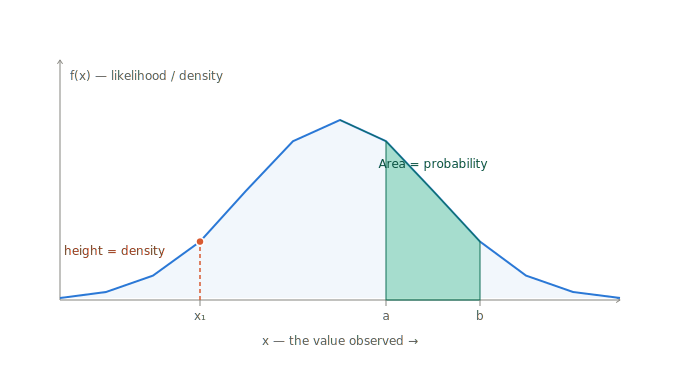

In [9]:
display(SVG(data=svg_string_6_small))

# Gaussian Naive Bayes

The flavor of Naive Bayes for **continuous features** — real-valued numbers like height, weight, or temperature, rather than word counts or presence/absence. A companion note to the Multinomial and Bernoulli notes.

**The Core Idea**



Gaussian NB asks a different question than the other two variants: **not** "how many times?" or "present or not?" but — **"what value, and how likely is that value on a bell curve?"**


```
Feature: height

Multinomial-style thinking:  doesn't apply — you can't "count" a height
Bernoulli-style thinking:    doesn't apply — height isn't 0/1
Gaussian thinking:           "5.8 ft — how likely is that value for this class?"
```

Instead of counting occurrences, Gaussian NB assumes each feature, **within each class**, follows a **normal (bell-curve) distribution** — described by just two numbers: a **mean (μ)** and a **standard deviation (σ)**.

<img src="https://media.geeksforgeeks.org/wp-content/uploads/20250514094215279104/Gaussian-Naive-Bayes.webp" width=400>

**The Formula**

$$P(x \mid y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \, e^{-\frac{(  x  -  \mu_y  )^2}{2  \sigma_y  ^2}}$$

Or simply: 

<img src ="https://cdn.builtin.com/cdn-cgi/image/f=auto/sites/www.builtin.com/files/styles/ckeditor_optimize/public/inline-images/7_gaussian-naive-bayes.jpg" width="300">



| Term | Meaning |
|---|---|
| `x` | the observed feature value (e.g. height = 5.8) |
| `μ_y` | the **mean** of that feature, computed only from class-`y` training examples |
| `σ_y` | the **standard deviation** of that feature, computed only from class-`y` examples |
| `P(x \mid y)` | the **height of class y's bell curve** at the point `x` — *not* a probability by itself, but a density used for comparison |

> **Key distinction from counting-based NB:** there's nothing to count here. Training just means computing `μ` and `σ` for each feature, per class. Prediction means plugging a new `x` into each class's curve and seeing which curve is taller there.


### 🎯 The One Thing That Makes Gaussian Different

Multinomial and Bernoulli both build their likelihoods from **frequencies** — counts of occurrences or presence. Gaussian throws frequency counting out entirely and instead fits a **smooth curve** to the data.

> *"Male heights cluster around 5.9 ft with some spread; female heights cluster around 5.4 ft with some spread. A new height of 5.7 ft — whose curve is it more consistent with?"*

This is the distribution view from the earlier note, made concrete: **each class is literally a bell curve over the feature**, and classification means checking whose curve is taller at the observed value.


### Worked Example

Classifying **gender from height**, using two features' worth of training stats:

| Class | Mean height (μ) | Std dev (σ) |
|---|---|---|
| Male | 5.9 ft | 0.3 |
| Female | 5.4 ft | 0.3 |

Priors: `P(Male) = 0.5`, `P(Female) = 0.5`.

**New observation: height = 5.7 ft**

Plug into the formula for each class:

```
P(5.7 | Male) = 1/√(2π×0.3²) × e^(-(5.7-5.9)²/(2×0.3²))
              = 1.33 × e^(-0.02/0.18)
              = 1.33 × e^(-0.111)
              ≈ 1.33 × 0.895 ≈ 1.19

P(5.7 | Female) = 1/√(2π×0.3²) × e^(-(5.7-5.4)²/(2×0.3²))
                = 1.33 × e^(-0.09/0.18)
                = 1.33 × e^(-0.5)
                ≈ 1.33 × 0.607 ≈ 0.81
```

**Combine with the priors (both 0.5, so they don't tip the scale here):**

```
Male score   = 0.5 × 1.19 = 0.595
Female score = 0.5 × 0.81 = 0.405
```

**Male wins** (0.595 vs 0.405) → classified **Male** ✅

Notice *why*: 5.7 ft sits closer to the Male mean (5.9) than the Female mean (5.4), so the Male bell curve is taller at that point — even though 5.7 ft is plausible for either class.



#### Gaussian vs Multinomial vs Bernoulli — When to Use Which

| | **Gaussian NB** | **Multinomial NB** | **Bernoulli NB** |
|---|---|---|---|
| Feature type | **continuous** (real numbers) | **counts** (0,1,2,3…) | **binary** (present/absent) |
| Learns per class | mean `μ` + std dev `σ` | word frequency proportions | presence proportions |
| Cares about | where the value falls on a bell curve | how often something occurs | whether something occurs at all |
| Best for | measurements: height, weight, sensor readings | longer text: topic/news classification | short text: spam, subject lines |
| No fixed vocabulary needed | ✅ — any real-valued feature | ❌ — needs a vocabulary | ❌ — needs a vocabulary |

**Rule of thumb:** if your feature is a **measurement** (something you'd naturally record with a decimal point), reach for **Gaussian**. If it's **word counts**, use Multinomial. If it's **word presence/absence**, use Bernoulli.

**In sklearn:** `GaussianNB` — no `alpha` smoothing parameter needed (there's no zero-count problem with continuous curves), though it does add a tiny "variance smoothing" term internally to avoid division-by-zero when `σ` is very small.


#### One-Page Recap

```
Feature      →  continuous real numbers (height, weight, temperature)
Formula      →  P(x|y) = (1/√(2πσ²)) · e^(-(x-μ)²/2σ²)   [the bell curve]
Learns       →  mean (μ) and std dev (σ) per feature, per class
No counting  →  fits a smooth curve instead of tallying occurrences
Classify     →  plug x into each class's curve, taller curve wins
Best for     →  measurements and sensor-style continuous data
sklearn      →  GaussianNB()  (no alpha needed)
```

## Mixing Naive Bayes Variants for Mixed Feature Types

Real data often isn't purely text or purely numbers — it's a **mix**: some categorical features, some continuous ones. Naive Bayes handles this gracefully because of one property: the **independence assumption**.

**The Key Insight**

Naive Bayes already assumes every feature is independent and just **multiplies** each one's contribution:

$$P(\text{Class} \mid \text{features}) \propto P(\text{Class}) \times P(f_1 \mid \text{Class}) \times P(f_2 \mid \text{Class}) \times \dots$$

Since each `P(fᵢ | Class)` is computed **separately**, nothing stops you from using a **different formula for each feature**, based on its type. Categorical features use the counting-based formula (Multinomial/Bernoulli-style); continuous features use the bell-curve formula (Gaussian-style). Then you just multiply everything together as usual.

> **In short:** you don't need one NB variant for the whole dataset — you pick the right likelihood formula per feature, and combine them in the same product.

**Simple Example**

Predicting whether someone **buys a product**, using two features:

| Feature | Type |
|---|---|
| `Ad Type` (Email / Social / Search) | **categorical** → use Multinomial-style counting |
| `Time on Site` (minutes, e.g. 4.2) | **continuous** → use Gaussian-style bell curve |

**Step 1 — Categorical feature (counting)**

From training data:
```
P(Ad Type = "Social" | Bought)     = 0.6
P(Ad Type = "Social" | Not Bought) = 0.2
```

**Step 2 — Continuous feature (bell curve)**

From training data, "Time on Site" per class:
```
Bought:     μ = 6.0 min, σ = 1.5
Not Bought: μ = 2.0 min, σ = 1.5
```

New customer spent `x = 5.0` minutes. Plug into the Gaussian formula for each class:

```
P(5.0 | Bought)     = (1/√(2π×1.5²)) × e^(-(5.0-6.0)²/(2×1.5²))  ≈ 0.212
P(5.0 | Not Bought) = (1/√(2π×1.5²)) × e^(-(5.0-2.0)²/(2×1.5²))  ≈ 0.017
```

**Step 3 — Combine (multiply everything together)**

New customer: **Ad Type = Social, Time on Site = 5.0 min**. Priors: `P(Bought) = 0.5`, `P(Not Bought) = 0.5`.

```
Bought score     = P(Bought)     × P(Social|Bought)     × P(5.0|Bought)
                 = 0.5 × 0.6 × 0.212  ≈ 0.0636

Not Bought score = P(Not Bought) × P(Social|Not Bought) × P(5.0|Not Bought)
                 = 0.5 × 0.2 × 0.017  ≈ 0.0017
```

**Bought wins** (0.0636 ≫ 0.0017) → predict **Bought** ✅

Notice the categorical feature used a simple lookup (0.6 vs 0.2), while the continuous feature used the bell-curve formula (0.212 vs 0.017) — **two completely different calculations, in the same multiplication**.



**Why This Works**

Each feature's `P(fᵢ | Class)` term is computed **independently of the others** — that's the entire "naive" assumption. Since it never asks "does this categorical feature interact with that continuous one," it doesn't care that they came from different formulas. It just needs a number between 0 and the density scale for each, and multiplies them all in.

**In Practice (sklearn)**

Scikit-learn doesn't have a single built-in "mixed" Naive Bayes — you typically:

1. Split features into categorical vs continuous groups.
2. Compute each feature's `P(fᵢ | Class)` with the matching formula (`CategoricalNB`/`MultinomialNB` logic for categorical, `GaussianNB` logic for continuous).
3. Multiply (or sum the logs of) all the pieces together per class, add the prior, and compare.

This is sometimes called a **"Mixed Naive Bayes"** or is done manually by combining `GaussianNB` and `CategoricalNB` predictions at the probability level.


**One-Page Recap**


```
Assumption   →  features are independent, so each P(fᵢ|Class) is separate
Categorical  →  use counting-based formula (Multinomial/Bernoulli-style)
Continuous   →  use bell-curve formula (Gaussian-style)
Combine      →  multiply every feature's term together, same as always
Result       →  one posterior score per class, mixing formula types freely
```

### Multinomial Naive Bayes — Scratch code

In [10]:
"""
Multinomial Naive Bayes — built from scratch, no sklearn.
Simplest possible version, for learning the mechanics behind
CountVectorizer + MultinomialNB.
"""

import math
from collections import Counter


class NaiveBayesScratch:
    def __init__(self, alpha=1.0):
        self.alpha = alpha          # Laplace smoothing constant
        self.class_priors = {}      # P(class)
        self.word_counts = {}       # word_counts[class][word] = count
        self.class_totals = {}      # total words seen in each class
        self.vocab = set()          # every word seen across all classes

    def _tokenize(self, text):
        return text.lower().split()

    def fit(self, texts, labels):
        classes = set(labels)
        n_docs = len(texts)

        for c in classes:
            self.word_counts[c] = Counter()
            self.class_totals[c] = 0

        # --- Step 1: count words per class ---
        for text, label in zip(texts, labels):
            words = self._tokenize(text)
            self.word_counts[label].update(words)
            self.class_totals[label] += len(words)
            self.vocab.update(words)
        

        # --- Step 2: class priors P(class) ---
        class_doc_counts = Counter(labels)
        for c in classes:
            self.class_priors[c] = class_doc_counts[c] / n_docs

        self.classes = classes
        self.vocab_size = len(self.vocab)

    def _log_likelihood(self, word, c):
        # P(word | class) with Laplace (add-alpha) smoothing:
        #   (count of word in class c + alpha) / (total words in c + alpha * vocab_size)
        count = self.word_counts[c][word]
        return math.log(
            (count + self.alpha) /
            (self.class_totals[c] + self.alpha * self.vocab_size)
        )

    def predict(self, text):
        words = self._tokenize(text)
        scores = {}

        for c in self.classes:
            # start with log P(class)
            log_prob = math.log(self.class_priors[c])
            # add log P(word|class) for every word — this is the
            # "naive" independence assumption: multiply likelihoods,
            # i.e. sum log-likelihoods
            for word in words:
                if word in self.vocab:          # skip unseen words
                    log_prob += self._log_likelihood(word, c)
            scores[c] = log_prob

        # argmax over classes
        predicted = max(scores, key=scores.get)
        return predicted, scores

In [11]:
# ---------------- demo: same spam/ham example from before ----------------
if __name__ == "__main__":
    texts = [
        "win money now",
        "free money win",
        "let us meet",
        "meet you now",
    ]
    labels = ["spam", "spam", "ham", "ham"]

    nb = NaiveBayesScratch(alpha=1.0)
    nb.fit(texts, labels)

    test_email = "free money now"
    pred, scores = nb.predict(test_email)

    print(f"Test email: '{test_email}'")
    print(f"Log-scores: {scores}")
    print(f"Predicted class: {pred}")
    test_email = "free money now"
    pred, scores = nb.predict(test_email)

    print(f"Test email: '{test_email}'")
    print(f"Log-scores: {scores}")
    print(f"Predicted class: {pred}")

Test email: 'free money now'
Log-scores: {'ham': -7.9171719888457766, 'spam': -6.125412519617721}
Predicted class: spam
Test email: 'free money now'
Log-scores: {'ham': -7.9171719888457766, 'spam': -6.125412519617721}
Predicted class: spam
